In [2]:

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os
import re
import shutil
import string
import tensorflow as tf
import numpy as np
import seaborn as sns
from tensorflow.keras import layers, losses
import matplotlib.pyplot as plt
from keras.saving import register_keras_serializable

In [4]:


url = "https://github.com/Monirekhonsari/text-classification/raw/main/6-persian-topics.zip"

zip_path = tf.keras.utils.get_file(
    "6-persian-topics.zip",
    url,
    extract=False,
    cache_dir='.',
    cache_subdir=''
)

print("ZIP downloaded at:", zip_path)

16473431/16473431 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
ZIP downloaded at: ./6-persian-topics.zip


In [5]:
! unzip 6-persian-topics.zip

Streaming output truncated to the last 5000 lines.
         continuing with "central" filename version
  inflating: 6-persian-topics/ورزش/452847.txt  
6-persian-topics/ورزش/452848.txt:  mismatching "local" filename (6-persian-topics/┘И╪▒╪▓╪┤/452848.txt),
         continuing with "central" filename version
  inflating: 6-persian-topics/ورزش/452848.txt  
6-persian-topics/ورزش/452849.txt:  mismatching "local" filename (6-persian-topics/┘И╪▒╪▓╪┤/452849.txt),
         continuing with "central" filename version
  inflating: 6-persian-topics/ورزش/452849.txt  
6-persian-topics/ورزش/452850.txt:  mismatching "local" filename (6-persian-topics/┘И╪▒╪▓╪┤/452850.txt),
         continuing with "central" filename version
  inflating: 6-persian-topics/ورزش/452850.txt  
6-persian-topics/ورزش/452851.txt:  mismatching "local" filename (6-persian-topics/┘И╪▒╪▓╪┤/452851.txt),
         continuing with "central" filename version
  inflating: 6-persian-topics/ورزش/452851.txt  
6-persian-topics/ورزش/452852.txt:

In [6]:
dataset_dir = '6-persian-topics'

sample_data = os.path.join(dataset_dir, 'ورزش/967579.txt')
with open(sample_data) as f:
  print(f.read())

batch_size = 32
seed = 42

raw_train_ds = tf.keras.utils.text_dataset_from_directory(
    dataset_dir,
    batch_size=batch_size,
    validation_split=0.2,
    subset='training',
    seed=seed)

raw_val_ds = tf.keras.utils.text_dataset_from_directory(
    dataset_dir,
    batch_size=batch_size,
    validation_split=0.2,
    subset='validation',
    seed=seed)

print("Classes:", raw_train_ds.class_names)

for text_batch, label_batch in raw_train_ds.take(1):
  for i in range(10):
    print("Review", text_batch.numpy()[i].decode()) #use decode for persian text
    print("Label", label_batch.numpy()[i])

for i in range(6):
  print("Label {} corresponds to {}".format(i, raw_train_ds.class_names[i]))







تور اندلس یا مسیر خورشید (اسپانیایی: Ruta del Sol‎) یک مسابقهٔ دوچرخه‌سواری حرفه‌ای است که به صورت سالانه در اسپانیا برگزار می‌شود. این مسابقه مرحله‌ای است و در میانهٔ فوریه انجام می‌شود. نخستین دورهٔ آن در سال ۱۹۲۵ برگزار شده‌است و از سال ۲۰۰۵ با درجهٔ یک بخشی از تور دوچرخه‌سواری اروپا محسوب می‌شود. نام مستعار آن، مسیر خورشید است که به ساحل گردشگری مشهور منطقه با نام ساحل خورشید اشاره دارد.
Found 37573 files belonging to 6 classes.
Using 30059 files for training.
Found 37573 files belonging to 6 classes.
Using 7514 files for validation.
Classes: ['بهداشت و سلامت', 'جغرافیا و مکانها', 'دین و اعتقاد', 'ریاضیات', 'فناوری و علوم کاربردی و تکنولوژی', 'ورزش']
Review آافیر (به لاتین: Aafir) در الجزایر با جمعیت ۱۲٬۶۱۳ نفر است که در استان بومرداس واقع شده‌است.
Label 1
Review نبردناو کلاس مونتانا (به انگلیسی: Montana-class battleship) یک کلاس از کشتی است که طول آن ۹۲۰ فوت ۶ اینچ (۲۸۰٫۵۷ متر) می‌باشد.
Label 4
Review کن فِم (به آلمانی: KenFM)، یک پایگاه خبری تحلیلی آلمانی است.
Label 4
Review شهرس

In [7]:
@register_keras_serializable()
def custom_standardization(input_data):
  text = tf.strings.lower(input_data)
  text = tf.strings.regex_replace(text, '<br />', ' ')
  text = tf.strings.regex_replace(text, 'ي', 'ی')
  text = tf.strings.regex_replace(text, 'ك', 'ک')
  text = tf.strings.regex_replace(text, 'ـ', '')
  text = tf.strings.regex_replace(text, '‌', ' ')
  text = tf.strings.regex_replace(text, r'[A-Za-z]', ' ')
  text = tf.strings.regex_replace(text, r'\d+', ' NUM ')
  text = tf.strings.regex_replace(text, '[%s]' % re.escape(string.punctuation), ' ')
  text = tf.strings.regex_replace(text, r'\s+', ' ')
  text = tf.strings.strip(text)
  return text

In [8]:



#Test the output of custom_standardization
txt = "   <br />  كشوري   کشوري‌  كــشـــورـي  Test123 !!!  سال ۱۴۰۲  "
print("Raw:", txt)
print("Clean:", custom_standardization(txt).numpy().decode())

max_features = 10000
sequence_length = 250

vectorize_layer = layers.TextVectorization(
    standardize=custom_standardization,
    max_tokens=max_features,
    output_mode='int',
    output_sequence_length=sequence_length)

# Make a text-only dataset (without labels), then call adapt
train_text = raw_train_ds.map(lambda x, y: x)
vectorize_layer.adapt(train_text)

def vectorize_text(text, label):
  text = tf.expand_dims(text, -1)
  return vectorize_layer(text), label

train_ds = raw_train_ds.map(vectorize_text)
val_ds = raw_val_ds.map(vectorize_text)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


Raw:    <br />  كشوري   کشوري‌  كــشـــورـي  Test123 !!!  سال ۱۴۰۲  
Clean: کشوری کشوری کشوری NUM سال ۱۴۰۲


In [9]:
embedding_dim = 16
model = tf.keras.Sequential([
  layers.Embedding(max_features, embedding_dim),
  layers.GlobalAveragePooling1D(),
  layers.Dense(100),
  layers.Dropout(0.5),
  layers.Dense(6)])

model.summary()

model.compile(loss=losses.SparseCategoricalCrossentropy(from_logits=True),
              optimizer='adam',
              metrics=['accuracy'])

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.keras",
    monitor='val_loss',
    save_best_only=True
)



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop, checkpoint]
)



Epoch 1/20
940/940 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6091 - loss: 1.0949 - val_accuracy: 0.8796 - val_loss: 0.4153
Epoch 2/20
940/940 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8860 - loss: 0.3719 - val_accuracy: 0.9090 - val_loss: 0.2697
Epoch 3/20
940/940 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9218 - loss: 0.2472 - val_accuracy: 0.9393 - val_loss: 0.2035
Epoch 4/20
940/940 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9431 - loss: 0.1855 - val_accuracy: 0.9452 - val_loss: 0.1706
Epoch 5/20
940/940 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9557 - loss: 0.1465 - val_accuracy: 0.9613 - val_loss: 0.1302
Epoch 6/20
940/940 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9630 - loss: 0.1223 - val_accuracy: 0.9690 - val_loss: 0.1099
Epoch 7/20
940/940 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9705 - loss: 0.1000 - val_accuracy: 0.9694 - val_loss: 0.1047
Epoch 8/20
940/940 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9741 - loss: 0.0880 - val_accuracy: 0.

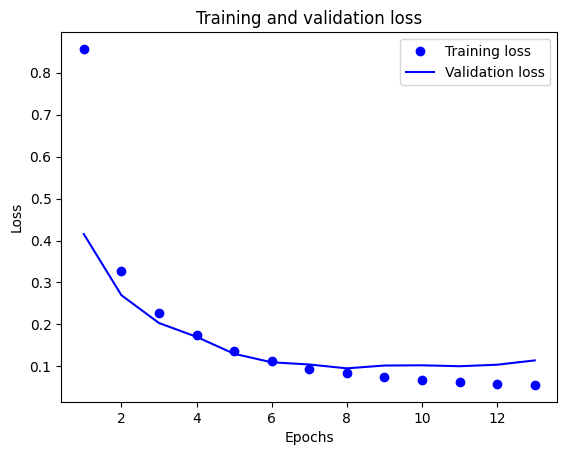

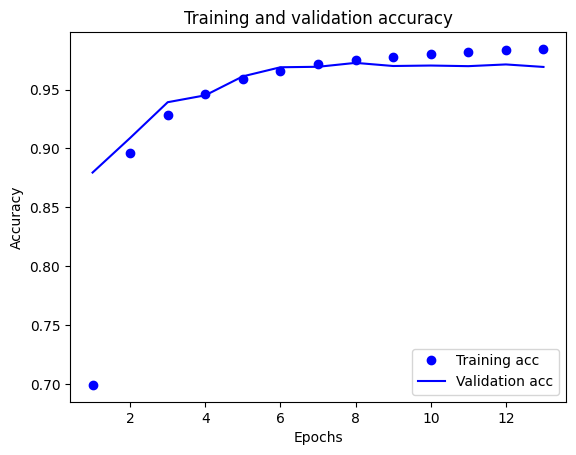

In [11]:

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# "bo" is for "blue dot"
plt.plot(epochs, loss, 'bo', label='Training loss')
# b is for "solid blue line"
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.show()

In [12]:
best_model = tf.keras.models.load_model("best_model.keras")

export_model = tf.keras.Sequential([
  vectorize_layer,
  best_model,
  layers.Activation('softmax')
])

export_model.compile(
    loss=losses.SparseCategoricalCrossentropy(from_logits=False), optimizer="adam", metrics=['accuracy']
)

loss, accuracy = export_model.evaluate(raw_val_ds)
print(accuracy)

export_model.save("final_export_model.keras")

examples =tf.constant( [
  "ویروس کرونا جان خیلی ها را گرفت",
  "فوتبال نوجوانان کشور با نتیجه 2 بر 0 به پایان رسید.",
  "تهران پایخت ایران است."
])

model = tf.keras.models.load_model("final_export_model.keras")
p = model.predict(examples)
results = np.argmax(p, axis=1)

for r in results:
  print(raw_train_ds.class_names[r])



235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9744 - loss: 0.0885
0.9727175831794739
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
جغرافیا و مکانها
ورزش
جغرافیا و مکانها


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 12 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 6.1 MB/s eta 0:00:00


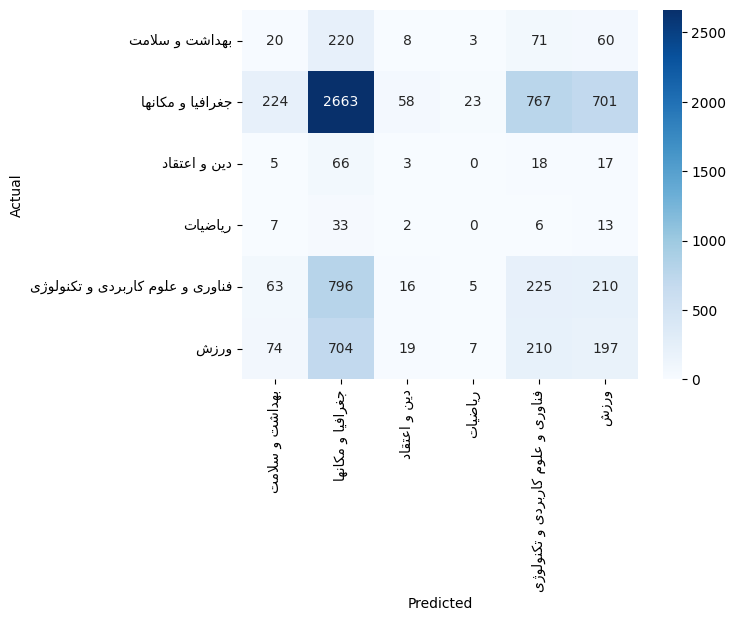

In [14]:

features = raw_val_ds.map(lambda x, y: x)
labels = raw_val_ds.map(lambda x, y: y)
predictions = export_model.predict(features)
predicted_classes = tf.math.argmax(predictions, axis=-1)

# Get the actual data from the MapDataset object
labels_list = list(labels.as_numpy_iterator())

# Flatten the batched labels
labels = np.concatenate(labels_list, axis=0)
confusion_mtx = tf.math.confusion_matrix(labels, predicted_classes)

!pip install arabic_reshaper

!pip install python-bidi

import arabic_reshaper
from bidi.algorithm import get_display

def convert_text(t):
    reshaped_text = arabic_reshaper.reshape(t) # seperated chars problem
    bidi_text = get_display(reshaped_text) #direction problem
    text = bidi_text.encode().decode('utf-8') #encoding problem (rectangular boxes!)
    return text

class_names = [convert_text(t) for t in raw_train_ds.class_names]

sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(np.arange(len(class_names))+0.5, class_names, rotation=90)
plt.yticks(np.arange(len(class_names))+0.5, class_names, rotation=0)

plt.show()


In [15]:
from sklearn.metrics import classification_report
report = classification_report(labels, predicted_classes)

for i in range(6):
  print("Label {} corresponds to {}".format(i, raw_train_ds.class_names[i]))
print(report)


Label 0 corresponds to بهداشت و سلامت
Label 1 corresponds to جغرافیا و مکانها
Label 2 corresponds to دین و اعتقاد
Label 3 corresponds to ریاضیات
Label 4 corresponds to فناوری و علوم کاربردی و تکنولوژی
Label 5 corresponds to ورزش
              precision    recall  f1-score   support

           0       0.05      0.05      0.05       382
           1       0.59      0.60      0.60      4436
           2       0.03      0.03      0.03       109
           3       0.00      0.00      0.00        61
           4       0.17      0.17      0.17      1315
           5       0.16      0.16      0.16      1211

    accuracy                           0.41      7514
   macro avg       0.17      0.17      0.17      7514
weighted avg       0.41      0.41      0.41      7514

